## Environment Setup


### Directory


In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))


### Standard Imports


In [3]:
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.utils.visualization.color_palette import set_color_palette
import skrom.problem_classes.masterclass as master
import importlib
import numpy as np
import matplotlib.pyplot as plt

# register problem (runs @register_problem)
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def")


### Plot Properties

In [4]:
import sci_mplstyle_package
set_color_palette();

In [5]:
generate_data = True
visualize = True
run_svd = True
run_rom = True
rom_report = True

## Full Order Simulation (Offline)


In [6]:
if generate_data:
    sim = master.fom_simulation(num_snapshots=16)
    sim.run_simulation()


Transforming over 1000 vertices to C_CONTIGUOUS.
Transforming over 1000 elements to C_CONTIGUOUS.
Transforming over 1000 vertices to C_CONTIGUOUS.
Transforming over 1000 elements to C_CONTIGUOUS.


Snap 1/32 params=[9.90322346 0.43570432]


Transforming over 1000 vertices to C_CONTIGUOUS.
Transforming over 1000 elements to C_CONTIGUOUS.


Snap 2/32 params=[3.98285445 0.32430992]
Snap 3/32 params=[4.04524269 0.32938291]
Snap 4/32 params=[6.09059096 0.21017601]
Snap 5/32 params=[7.91051599 0.35849721]
Snap 6/32 params=[5.95975386 0.24331386]
Snap 7/32 params=[2.02238767 0.41037904]
Snap 8/32 params=[8.0981262  0.28738319]
Snap 9/32 params=[8.71377863 0.35294512]
Snap 10/32 params=[2.66454768 0.2181075 ]
Snap 11/32 params=[5.35190696 0.42826064]
Snap 12/32 params=[7.27617534 0.30123552]
Snap 13/32 params=[6.72100871 0.40268553]
Snap 14/32 params=[4.6413875 0.2640704]
Snap 15/32 params=[3.32898948 0.3822978 ]
Snap 16/32 params=[9.28365099 0.25149518]
Snap 17/32 params=[6.88158309 0.29139606]
Snap 18/32 params=[4.19592176 0.41292445]
Snap 19/32 params=[2.05511042 0.24534172]
Snap 20/32 params=[8.86552741 0.36595553]
Snap 21/32 params=[9.31793531 0.22276058]
Snap 22/32 params=[3.51142446 0.34142126]
Snap 23/32 params=[5.74537545 0.29835217]
Snap 24/32 params=[7.42713065 0.42183369]
Snap 25/32 params=[7.982885   0.25807897]
Sn

### Load Simulation data


In [7]:
# Load saved ROM_data (works even if 'generate=False')
rom_data = master.rom_simulation()

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\static\linear\problem_2\ROM_data


### Generate Training Solution Dataset

In [8]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = rom_data.param_list

# Load solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(rom_data.fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = rom_data.train_mask, rom_data.test_mask

# Apply masks to filter solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available
### Mean Subtraction

32


### Mean Subtraction

In [9]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Vizualize Mesh

Warning: VTK requires 3D points, but 2D points given. Appending 0 third component.

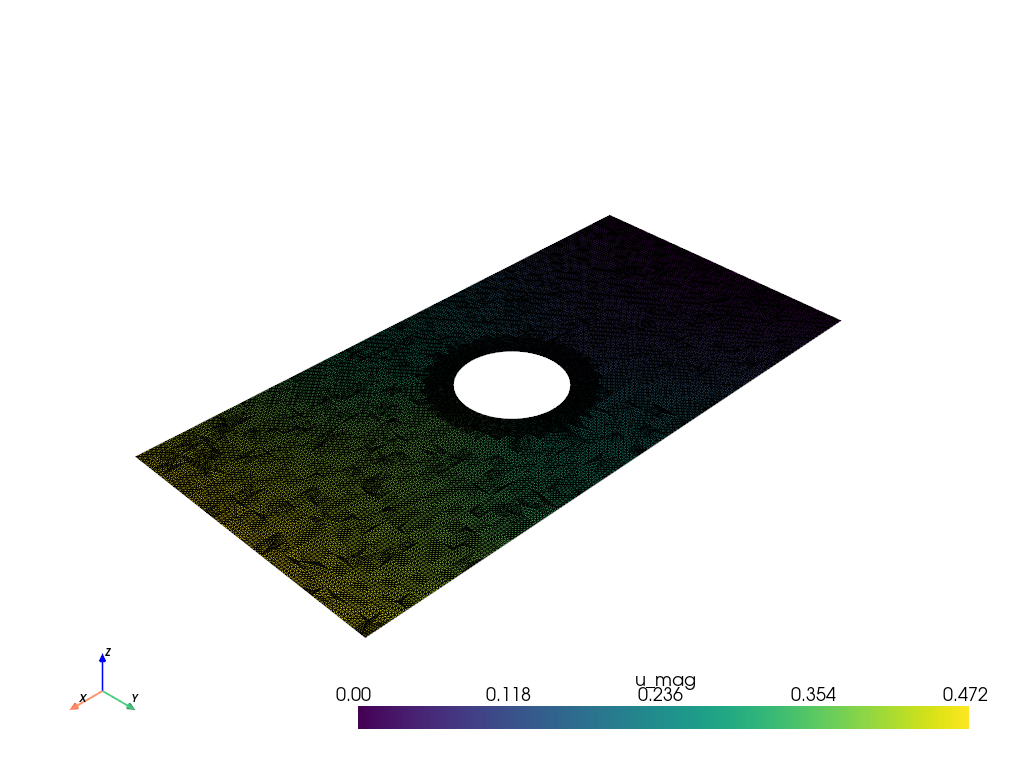

In [12]:
if visualize:
    from skfem import Basis
    from skfem.element import ElementTriP1, ElementVector
    import pyvista as pv

    element = ElementVector(ElementTriP1())
    basis_vec = Basis(rom_data.mesh, element)

    # Extract nodal displacements
    u_node = LS_train[0][basis_vec.nodal_dofs]  # shape (2, n_nodes)
    ux = u_node[0, :]
    uy = u_node[1, :]

    # Save to VTK (ParaView-readable)
    rom_data.mesh.save(
        "plate_with_hole_solution.vtk",
        point_data={
            "u_x": ux,
            "u_y": uy,
            "u_mag": (ux**2 + uy**2)**0.5,
        }
    )

    pv.set_jupyter_backend("static")

    mesh = pv.read("plate_with_hole_solution.vtk")
    mesh.plot(scalars="u_mag", cmap="viridis", show_edges=True)

## POD Basis (Offline ROM step)


Number of modes selected: 4


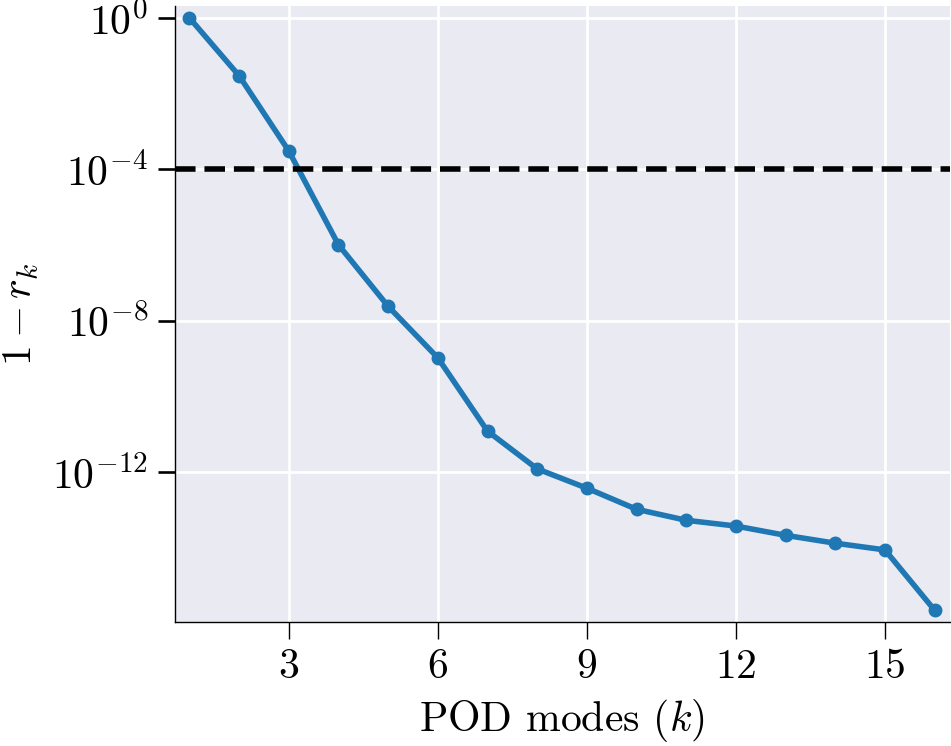

In [13]:
if run_svd:

    # fig, ax = plt.subplots(figsize=(5,3.5))
    plt.rcParams['lines.markersize'] = 6
    plt.rcParams['lines.linewidth'] = 2.0

    n_sel, U = svd_mode_selector(LS_train_ms, tolerance = 1e-4, modes=True)
    V_sel = U[:, :n_sel]
    plt.ylabel('$1-r_{k}$')
    plt.xlabel('POD modes ($k$)')


## ROM Simulation (Online)


In [14]:
if run_rom:
    # Initialize the reduced-order model (ROM) simulation with affine decomposition for speed-up
    #   V_sel : precomputed basis matrix (e.g., selected POD modes)
    rom = master.rom_simulation(V_sel=V_sel,train_ref=LS_train_mean)

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\static\linear\problem_2\ROM_data


In [15]:
if run_rom:
    # Run the reduced-order model (ROM) simulation.
    # rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
    rom.run_rom_simulation();

Snap 1/16 params=[6.88158309 0.29139606]
Snap 2/16 params=[4.19592176 0.41292445]
Snap 3/16 params=[2.05511042 0.24534172]
Snap 4/16 params=[8.86552741 0.36595553]
Snap 5/16 params=[9.31793531 0.22276058]
Snap 6/16 params=[3.51142446 0.34142126]
Snap 7/16 params=[5.74537545 0.29835217]
Snap 8/16 params=[7.42713065 0.42183369]
Snap 9/16 params=[7.982885   0.25807897]
Snap 10/16 params=[5.15659867 0.38447585]
Snap 11/16 params=[3.07877371 0.27080816]
Snap 12/16 params=[9.77981569 0.40227003]
Snap 13/16 params=[8.29426583 0.31096735]
Snap 14/16 params=[2.59712998 0.44047609]
Snap 15/16 params=[4.64407115 0.20229476]
Snap 16/16 params=[6.46645135 0.33064477]


In [16]:
if rom_report:
    #Assign values for the statistics
    LS_rom = np.asarray(rom.rom_solutions)
    ROM_speed_up = rom.speed_up
    ROM_speed_up=ROM_speed_up[1:]
    ROM_relative_error = rom.rom_error

ROM Accuracy Report

Global Errors:
L2 Error:                 2.0520e-06
Relative L2 Error:        7.9059e-08
L∞ Error:                 7.3100e-07
Relative L∞ Error:        3.1971e-07
RMSE:                     3.5507e-08
MAE:                      1.3971e-08

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             2.4303e-12
95th Percentile Error:    6.3385e-08

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.6925e-09
Max Rel L2 Error over time/parameter: 1.0490e-08
Min Rel L2 Error over time/parameter: 4.0902e-11
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

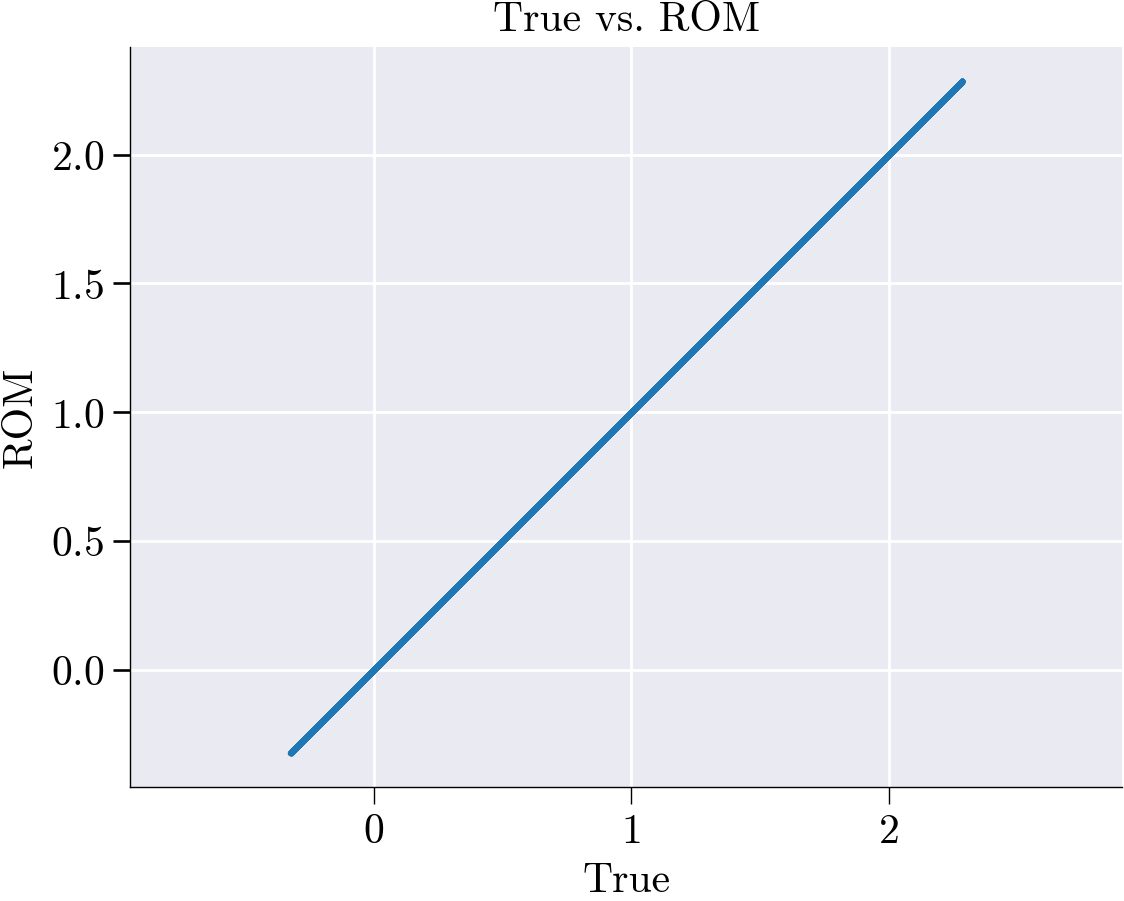

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


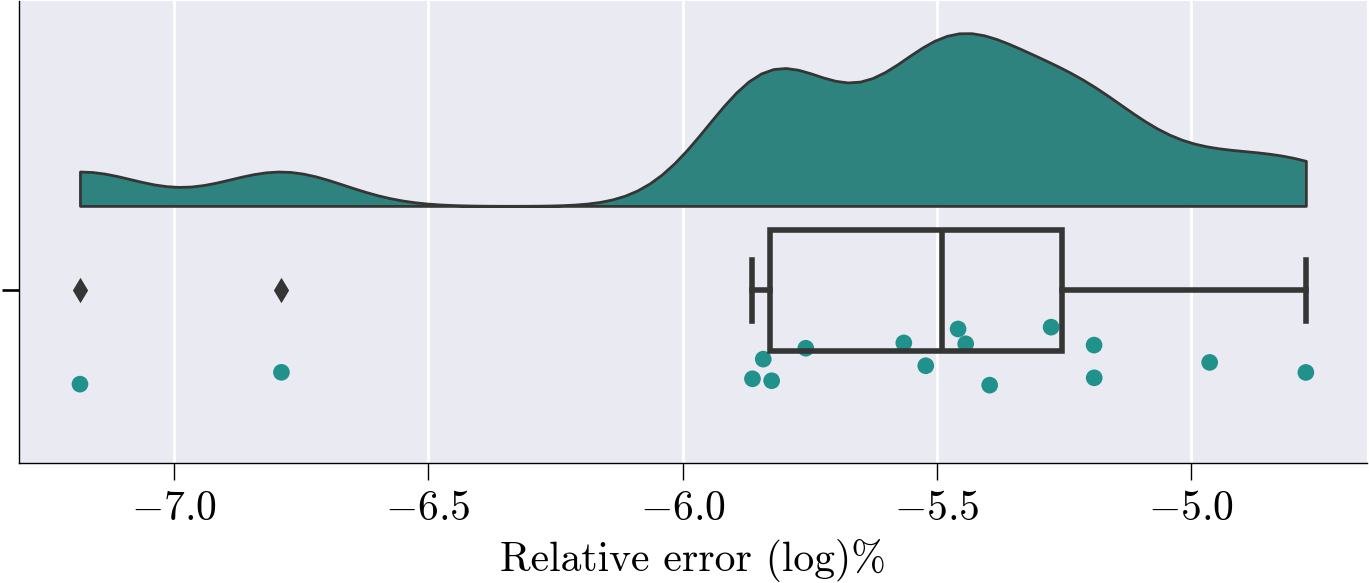

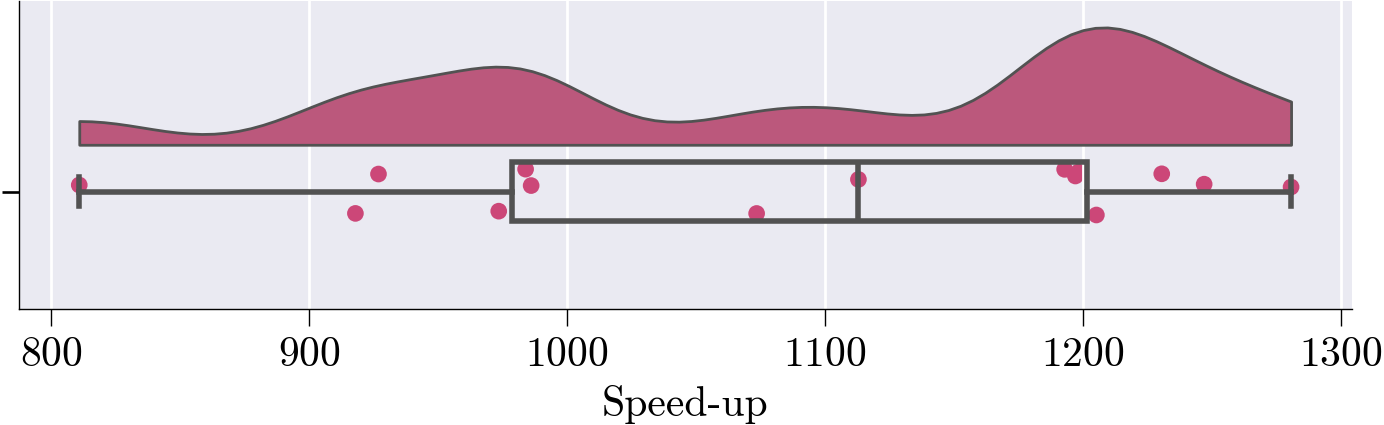

In [17]:
if rom_report:
    # --- ROM error analysis ---

    # Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
    matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)

    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)

    # Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
    plot_rom_error_diagnostics_flat(
        LS_test,                   # full-order (true) solution snapshots
        LS_rom,              # hyper-ROM-generated solution snapshots
        ROM_relative_error,   # precomputed relative error of the hyper-ROM
        ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
        sim_axis=['True', 'ROM'], 
        metrics=matrix              # the matrix of error metrics just computed
    )

## Post-processing: Stress components and von Mises


Test param (E, nu): 6.881583094596863 0.2913960572797805
von Mises max (FOM, ROM): 3.5452044717981086 3.545204598991833


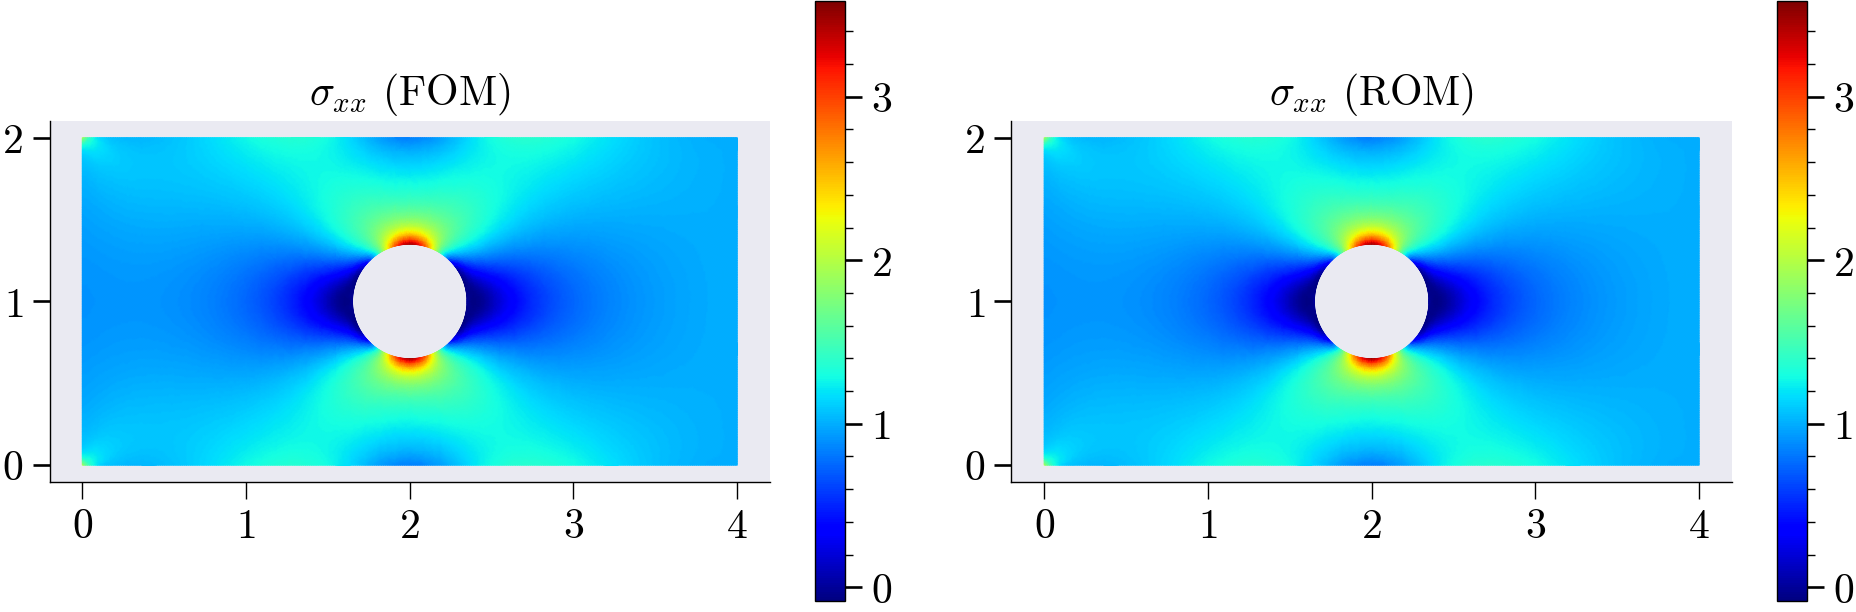

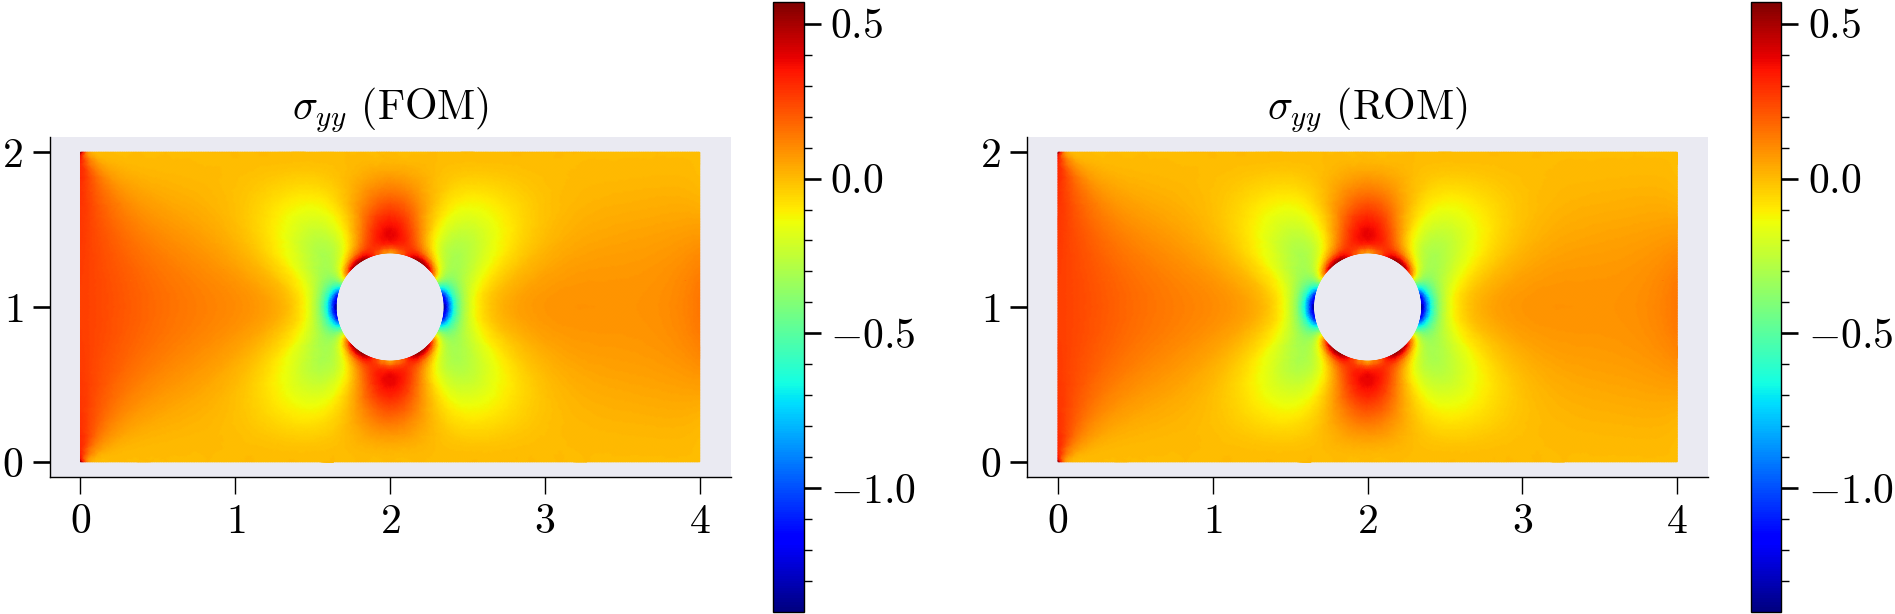

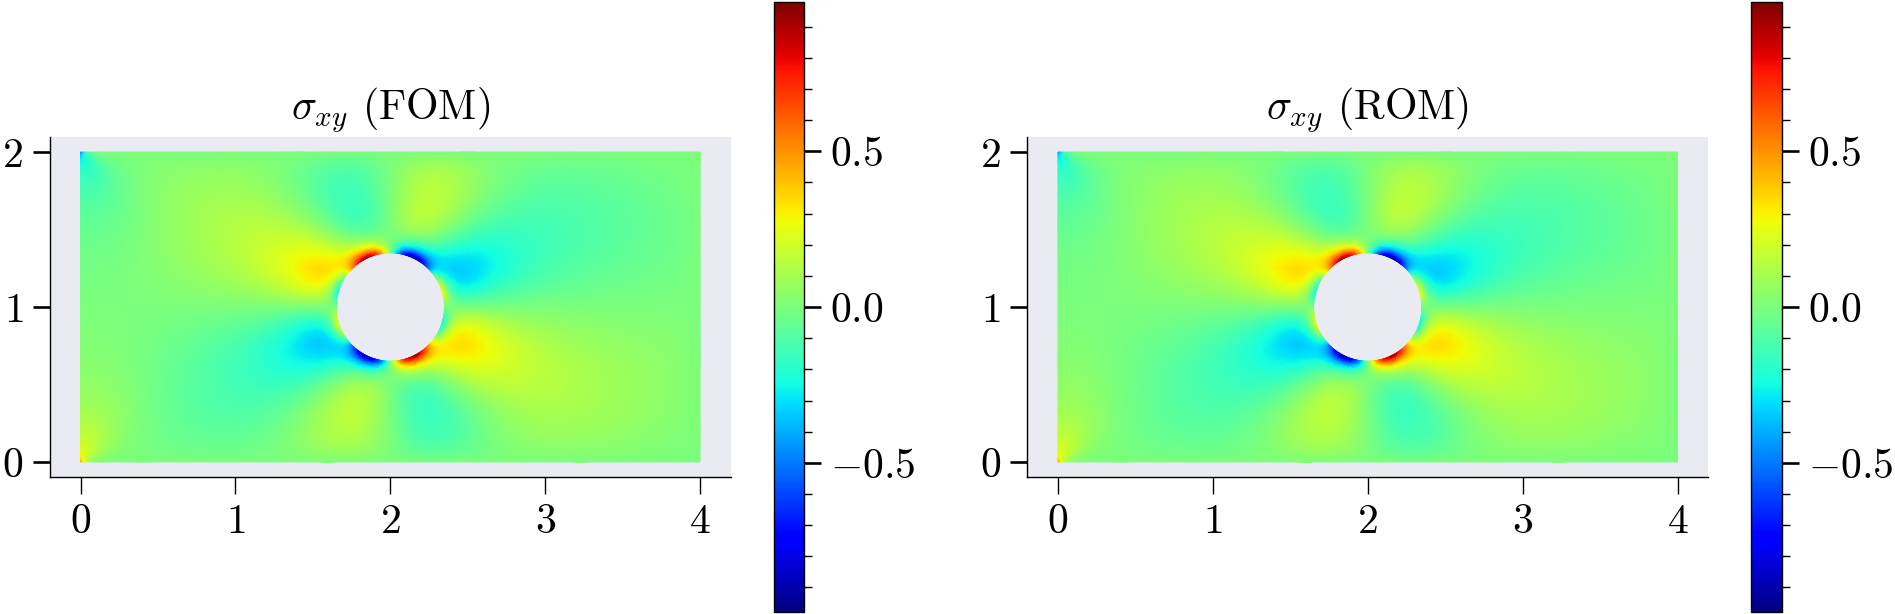

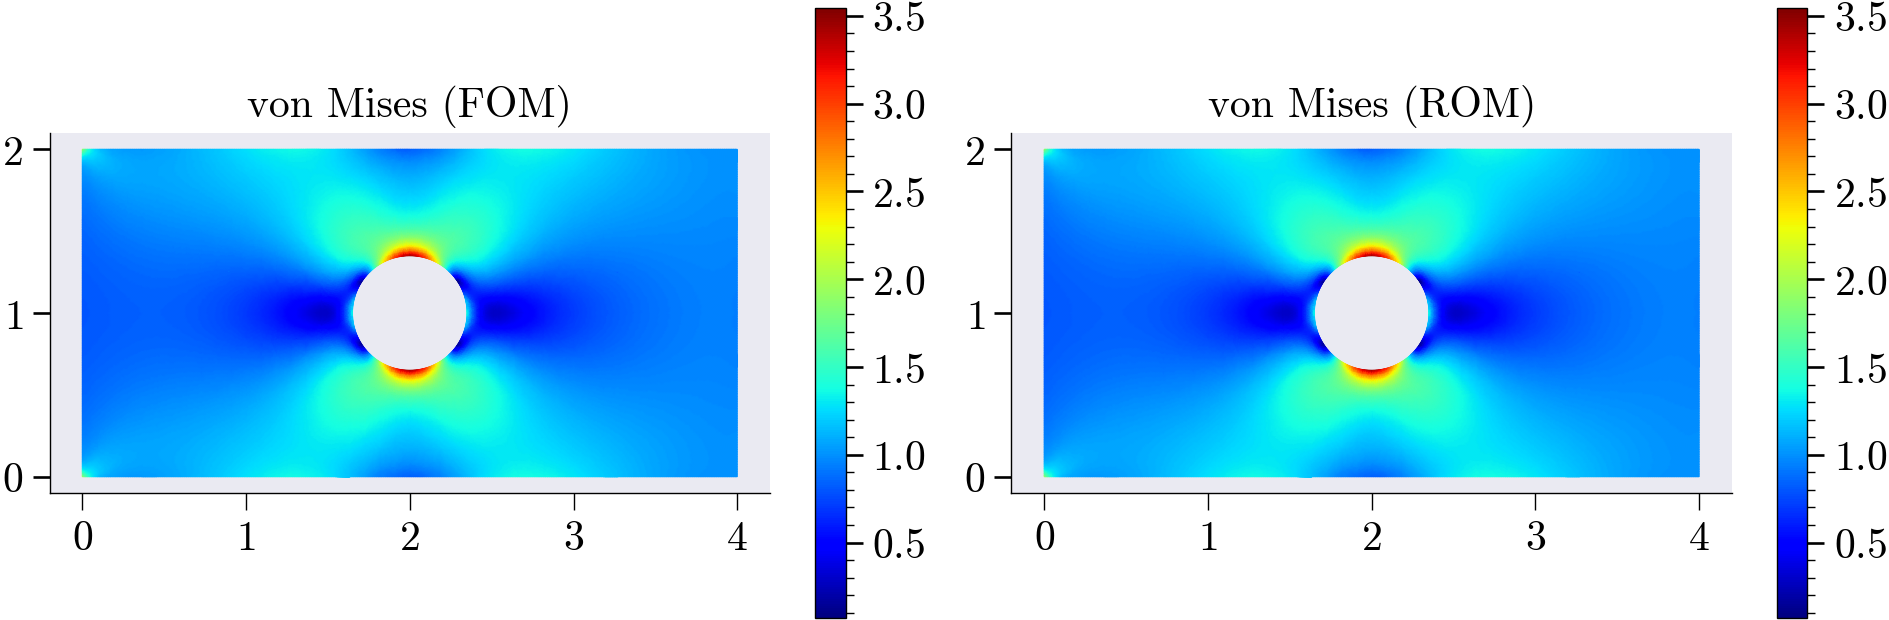

Relative error (von Mises, nodal L2): 1.444626271619672e-08


In [20]:
from skfem import Basis, ElementTriP1
from skfem.visuals.matplotlib import plot

def compute_nodal_stress_plane_stress(mesh, u_full, E, nu):
    """
    Compute nodal stresses for P1 triangle displacement (vector P1).

    Returns nodal arrays:
        sxx, syy, sxy, von_mises
    """
    # node coords and connectivity
    p = mesh.p.T  # (n_nodes, 2)
    t = mesh.t.T  # (n_elems, 3)
    n_nodes = p.shape[0]
    n_elems = t.shape[0]

    # nodal displacement components (assumes u_full contains nodal dofs first)
    # For vector P1 in skfem: basis.nodal_dofs has shape (2, n_nodes)
    basis_vec = rom_data.basis
    u_node = u_full[basis_vec.nodal_dofs]  # (2, n_nodes)
    ux = u_node[0, :]
    uy = u_node[1, :]

    # element node indices
    i1, i2, i3 = t[:, 0], t[:, 1], t[:, 2]

    x1, y1 = p[i1, 0], p[i1, 1]
    x2, y2 = p[i2, 0], p[i2, 1]
    x3, y3 = p[i3, 0], p[i3, 1]

    # triangle area (2A in denominator)
    twoA = (x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1)

    # gradients for P1
    dN1dx = (y2 - y3) / twoA
    dN1dy = (x3 - x2) / twoA
    dN2dx = (y3 - y1) / twoA
    dN2dy = (x1 - x3) / twoA
    dN3dx = (y1 - y2) / twoA
    dN3dy = (x2 - x1) / twoA

    # gather displacements per element
    ux1, uy1 = ux[i1], uy[i1]
    ux2, uy2 = ux[i2], uy[i2]
    ux3, uy3 = ux[i3], uy[i3]

    # strain components (small strain)
    exx = dN1dx * ux1 + dN2dx * ux2 + dN3dx * ux3
    eyy = dN1dy * uy1 + dN2dy * uy2 + dN3dy * uy3
    gxy = (dN1dy * ux1 + dN2dy * ux2 + dN3dy * ux3) + (dN1dx * uy1 + dN2dx * uy2 + dN3dx * uy3)

    # plane stress constitutive
    fac = E / (1.0 - nu**2)
    sxx_e = fac * (exx + nu * eyy)
    syy_e = fac * (nu * exx + eyy)
    sxy_e = (E / (2.0 * (1.0 + nu))) * gxy

    vm_e = np.sqrt(sxx_e**2 - sxx_e*syy_e + syy_e**2 + 3.0*sxy_e**2)

    # nodal averaging
    sxx = np.zeros(n_nodes); syy = np.zeros(n_nodes); sxy = np.zeros(n_nodes); vm = np.zeros(n_nodes)
    cnt = np.zeros(n_nodes)

    for arr_e, arr_n in [(sxx_e, sxx), (syy_e, syy), (sxy_e, sxy), (vm_e, vm)]:
        np.add.at(arr_n, i1, arr_e)
        np.add.at(arr_n, i2, arr_e)
        np.add.at(arr_n, i3, arr_e)

    np.add.at(cnt, i1, 1.0); np.add.at(cnt, i2, 1.0); np.add.at(cnt, i3, 1.0)
    cnt_safe = np.where(cnt > 0.0, cnt, 1.0)
    sxx /= cnt_safe; syy /= cnt_safe; sxy /= cnt_safe; vm /= cnt_safe

    return sxx, syy, sxy, vm


scalar_basis = Basis(mesh, ElementTriP1())

# pick a test snapshot to compare
idx = 0
param = param_list[test_mask][idx]
E, nu = float(param[0]), float(param[1])

u_fom = LS_test[idx]
u_rom = LS_rom[idx]

sxx_f, syy_f, sxy_f, vm_f = compute_nodal_stress_plane_stress(mesh, u_fom, E, nu)
sxx_r, syy_r, sxy_r, vm_r = compute_nodal_stress_plane_stress(mesh, u_rom, E, nu)

print("Test param (E, nu):", E, nu)
print("von Mises max (FOM, ROM):", np.max(vm_f), np.max(vm_r))

def plot_pair(title, a, b):
    fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
    plot(scalar_basis, a, ax=axs[0], shading='gouraud', colorbar=True)
    axs[0].set_title(title + " (FOM)")
    plot(scalar_basis, b, ax=axs[1], shading='gouraud', colorbar=True)
    axs[1].set_title(title + " (ROM)")
    for ax in axs: ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

plot_pair(r"$\sigma_{xx}$", sxx_f, sxx_r)
plot_pair(r"$\sigma_{yy}$", syy_f, syy_r)
plot_pair(r"$\sigma_{xy}$", sxy_f, sxy_r)
plot_pair(r"von Mises", vm_f, vm_r)

# stress-field relative error (nodal)
rel_vm = np.linalg.norm(vm_f - vm_r) / np.linalg.norm(vm_f)
print("Relative error (von Mises, nodal L2):", rel_vm)
